## Tokenization


For transformers, a fundamental step is to convert the input text into a sequence of tokens. Tokenizers are used for this purpose. Different tokenization techniques can be used (e.g., Byte-Pair Encoding).

These tokenizers need to be trained on some corpus (e.g., to figure out what the most common words are). However, the Hugging Face library provides pre-trained tokenizers that can be used out of the box.

Generally, each model has its own tokenizer. For example, the `BertTokenizer` is used for BERT models, and the `GPT2Tokenizer` is used for GPT-2 models.


Since we will be using T5 for this exercise, we should be using the `T5Tokenizer` class. However, HuggingFace provides a common `AutoTokenizer` class that can be used to load the appropriate tokenizer for a given model  (do note, however, that the returned class will be the "correct" one!).

In [1]:
from transformers import AutoTokenizer

model_name = "google-t5/t5-base"  # T5: encoder-decoder - Great for translation, summarization, and answering questions.

tokenizer = AutoTokenizer.from_pretrained(model_name)

# TODO: print the type of the tokenizer
print(type(tokenizer))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

<class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>


### Encoding/Decoding

Tokenization can be carried out by passing a string that we want to tokenize. The tokenizer implements the `__call__` method, so we can call the tokenizer directly, as follows.

Note that the output is a dictionary, which generally has the following keys:

- `input_ids`: The tokenized input text (a list of token IDs by default).
- `attention_mask`: A mask that indicates which elements in the input text are tokens and which are padding tokens. For now, we can ignore this (there is no padding). It will instead become useful when we encode batches of sentences of different lengths at the same time.

In [2]:
sentence = "hello, this is a sentence!" # 8 tokens

# TODO: use the tokenizer to tokenize the sentence and print the result
tokens = tokenizer(sentence)
print(tokens)

# An attention mask is a simple array of 1s and 0s that tells a machine learning model
# which tokens (words/sub-words) it should look at and which ones it should ignore.

{'input_ids': [21820, 6, 48, 19, 3, 9, 7142, 55, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


We can reverse the encoding operation (i.e., going from token IDs to strings) by using the `decode` method of the tokenizer.

In [3]:
tokenizer.decode(tokens["input_ids"]) # [21820, 6, 48, 19, 3, 9, 7142, 55, 1]

'hello, this is a sentence!</s>'

In [4]:
tokenizer.decode(tokenizer.encode(sentence))

'hello, this is a sentence!</s>'

In [5]:
tokenizer.encode(sentence)

[21820, 6, 48, 19, 3, 9, 7142, 55, 1]

Note that we have an extra part at the end of the string, which is the special token `</s>`. This token is used to indicate the end of the input text (EOS). This token is automatically added by the tokenizer when encoding the input text.

To learn what the mapping between tokens and token IDs is, we can get the tokenizer's vocabulary (`.get_vocab()`), which provides the mapping between tokens and respective IDs.

For convenience, we build also a reverse vocabulary (i.e., from IDs to tokens).

In [6]:
import random

vocabulary = tokenizer.get_vocab() # dictionary word -> ID
# print(vocabulary)

# TODO: print 10 random words from the vocabulary

reverse_vocab = {value:key for key,value in vocabulary.items()}
vocab_keys = list(vocabulary.keys())

# reverse_vocab = {}
# vocab_keys = []
# for key,value in vocabulary.items():
#   reverse_vocab[value] = key
#   vocab_keys.append(key)

# print(reverse_vocab)
# print(vocab_keys)

random.shuffle(vocab_keys)
# print(vocab_keys)

{k:vocabulary[k] for k in vocab_keys[10:20]}
# random_words = {}
# for k in vocab_keys[:10]:
#   val = vocabulary[k]
#   random_words[k] = val
# print(random_words)

{'▁sealed': 16645,
 '▁disconnect': 25937,
 '▁Clip': 17399,
 '▁courteous': 28490,
 '▁Forschung': 13764,
 '▁inspirat': 23121,
 'rance': 5219,
 '▁BBQ': 15068,
 '▁mensuel': 31839,
 '▁dintr': 10085}

In [7]:
print("Total vocabulary size:", len(vocabulary))

Total vocabulary size: 32100


We have a total of 32100. For T5, that's 32000 tokens + 100 special tokens (<extra_id_0>, <extra_id_1>, ..., <extra_id_99>) -- used for the tasks that T5 was trained on.

Let's see what the token id for the special token `</s>` is.

In [8]:
vocabulary["</s>"]

1

And indeed, note that our `tokens` has a 1 showing up at the end!

In [9]:
tokens["input_ids"]

[21820, 6, 48, 19, 3, 9, 7142, 55, 1]

We can include special tokens inside of the strings themselves. For instance:

In [10]:
tokenizer("hello!</s></s>")

{'input_ids': [21820, 55, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1]}

Here, we have 2 `</s>` tokens (the ones we specified), plus an additional one that was added by the tokenizer.

Instead of getting token IDs directly, we may look at the tokens being produced, directly. We use the `tokenize()` method in this case.

In [11]:
tokenizer.tokenize(sentence)

['▁hello', ',', '▁this', '▁is', '▁', 'a', '▁sentence', '!']

What's up with those `_`? They simply represent words that are starting after spaces. This helps us understand whether a token is being used at the beginning of a sentence, or if it's in the middle of a word.

In [12]:
print(tokenizer.tokenize("hello    ,world"))
print(tokenizer.tokenize("hello    , world"))
# tokenize:  takes a raw string of text (a normal human sentence) and chops it up into smaller, model-readable pieces called tokens.

['▁hello', '▁', ',', 'world']
['▁hello', '▁', ',', '▁world']


In the above case, `_hello` is the token for the word "hello" at the beginning of the sentence. However, the word "world" is mapped to two different tokens, depending on whether there is a space before the word or not.

Notice also how multiple spaces are compacted into a single one!

These are all tokenizer-specific details. The tokenizer is responsible for deciding how to tokenize the input text. You may observe different behaviors for different tokenizers.

### Special tokens

Each model typically has its own special tokens. Some are necessary for the training process, while others can be beneficial at inference time.

Special attributes are available in the tokenizer class to access these special tokens. Some examples are:

- `pad_token` is the token used for padding (as discussed later),
- `bos_token` and `eos_token` tokens are used to indicate the beginning and end of the input text, respectively,
- `mask_token` is used for masking tokens during training (e.g., for the masked LM task, with BERT),
- `sep_token` is used to separate sentences in the input text (e.g., next sentence prediction, with BERT),
- `cls_token` is used to indicate the beginning of the input text (e.g., for classification tasks, with BERT),
- `unk_token` is used to indicate unknown tokens (i.e., tokens that are not in the vocabulary).

Of course, not all tokenizers will use all tokens. So those attributes will be set to None, if not used.

For instance, T5 has EOS and PAD tokens, but no BOS token.

In [13]:
tokenizer.eos_token, tokenizer.pad_token, tokenizer.bos_token

('</s>', '<pad>', None)

The `_id` suffix is used to indicate the corresponding token ID (None if not applicable).

In [14]:
tokenizer.eos_token_id, tokenizer.pad_token_id, tokenizer.bos_token_id

(1, 0, None)

### Batch encoding/decoding

In general (especially at training time) we will want to encode multiple sentences at once (e.g., an entire batch of sentences).

We can pass a list of sentences to be encoded to the tokenizer.

In [15]:
sentences = [
    "this is the first sentence",
    "instead, this is the second sequence!"
]

#TODO: use the tokenizer to tokenize the sentences and print the result
tokens = tokenizer(sentences)

for token in tokens['input_ids']:
  print(token)

[48, 19, 8, 166, 7142, 1]
[1446, 6, 48, 19, 8, 511, 5932, 55, 1]


Of course, sentences of different lengths have a different number of tokens! However, tensors (that will be used by the model) need to have the same number of elements along each dimension.

To do this, we can use padding: all sentences will be padded to the length of the longest sentence in the batch. This is done by adding `pad` tokens (`<pad>`, for T5).

However, since the pad tokens are not part of the input text, we need to let the model know that it should not pay attention to them. That's what the `attention_mask` is for!

In [16]:
#TODO: use the tokenizer to tokenize the sentences with padding and print the result (use padding=True)
tokens = tokenizer(sentences,padding= True)

for token in tokens['input_ids']:
  print(token)
for att in tokens['attention_mask']:
  print(att)

for token,att in zip(tokens['input_ids'],tokens['attention_mask']):
  print(token,att)
# same length by adding padding
# zip takes two or more lists and pairs their elements together, side-by-side, based on their position.

[48, 19, 8, 166, 7142, 1, 0, 0, 0]
[1446, 6, 48, 19, 8, 511, 5932, 55, 1]
[1, 1, 1, 1, 1, 1, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1]
[48, 19, 8, 166, 7142, 1, 0, 0, 0] [1, 1, 1, 1, 1, 1, 0, 0, 0]
[1446, 6, 48, 19, 8, 511, 5932, 55, 1] [1, 1, 1, 1, 1, 1, 1, 1, 1]


The first sentence is padded to the same length as the second sentence, with 0's (remember, the ID for `<pad>`!).

The attention mask for the first sentence also contains 0's for the padding tokens: the model will ignore them when processing the input text.

Since now all sentences have the same length, we can stack them into a single tensor. Luckily, the tokenizer can already do this for us, we just need to ask.


In [17]:
#TODO: use the tokenizer to tokenize the sentences with padding as a tensor and print the result (use padding=True and return_tensors="pt")
tokens = tokenizer(sentences,padding= True,return_tensors ="pt")

print(tokens["input_ids"])
print(tokens["attention_mask"])
print(tokens["input_ids"].shape)
print(tokens["attention_mask"].shape)

tensor([[  48,   19,    8,  166, 7142,    1,    0,    0,    0],
        [1446,    6,   48,   19,    8,  511, 5932,   55,    1]])
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])
torch.Size([2, 9])
torch.Size([2, 9])


For completeness, we can also decode batches of sentences, with `tokenizer.batch_decode()`.

In [18]:
tokenizer.batch_decode(tokens["input_ids"]) # multiple sentences at once.

['this is the first sentence</s><pad><pad><pad>',
 'instead, this is the second sequence!</s>']

In [19]:
tokenizer.decode(tokens["input_ids"]) # single sentence

['this is the first sentence</s><pad><pad><pad>',
 'instead, this is the second sequence!</s>']

## Model analysis

Now we can go ahead and finally load our T5 model. We once again use a pretrained version available on HuggingFace.

In general, we could use the `AutoModel` class for the loading, of the model. However, that version of the model does not include the specific heads for the tasks that T5 was trained on.

The transformers library can make our life easier by defining a family of `AutoModel...` classes.

For instance, the following are some commonly adopted classes:
- `AutoModel`: the base class for all models,
- `AutoModelForSequenceClassification`: a model for sequence classification tasks. It consists of a base model plus a classification head (linear layer + softmax). Note that, generally, the classification head is initialized randomly, and it needs to be trained on the specific task (but the library will let you know with a warning),
- `AutoModelForCaualLM`: a model for causal language modeling tasks (e.g., GPT-2), where we generate the output tokens one by one,
- `AutoModelForMaskedLM`: a model for masked language modeling tasks (e.g., BERT), where we predict the masked tokens in the input text,
- `AutoModelForTokenClassification`: a model for token classification tasks (e.g., NER), where we classify each token in the input text.
- `AutoModelForSeq2SeqLM`: a model for sequence-to-sequence tasks (e.g., T5), where we generate the output tokens one by one in an autoregressive manner, conditioned on the input sequence.

In our specific case, we will use the `AutoModelForSeq2SeqLM` class to be able to generate new tokens.

In [20]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# TODO: print the type of the model
print(type(model))

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

<class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>


To better understand the model, we can take a look at the model's configuration. The configuration contains all the hyperparameters of the model. The configuration is available as a dictionary, and we can access the values by using the attribute notation.

You can find the model's configuration object in the `config` attribute of the model. Or, if you only need the configuration, you can directly load it using the `AutoConfig` class.

```python
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name)
```

In [21]:
model.config

T5Config {
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 3072,
  "d_kv": 64,
  "d_model": 768,
  "decoder_start_token_id": 0,
  "dense_act_fn": "relu",
  "dropout_rate": 0.1,
  "dtype": "float32",
  "eos_token_id": 1,
  "feed_forward_proj": "relu",
  "initializer_factor": 1.0,
  "is_decoder": false,
  "is_encoder_decoder": true,
  "is_gated_act": false,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 12,
  "num_heads": 12,
  "num_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "scale_decoder_outputs": true,
  "task_specific_params": {
    "summarization": {
      "early_stopping": true,
      "length_penalty": 2.0,
      "max_length": 200,
      "min_length": 30,
      "no_repeat_ngram_size": 3,
      "num_beams": 4,
      "prefix": "summarize: "
    },
    "translation_en_to_de": {
      "ear

Lots of information going on here. We can just take a few key aspects:

- `d_kv` = 64. This is the dimension of keys $d_k$ (so also queries) and values $d_v$ in the attention mechanism. It is common, to keep things simple, to use the same number of dimensions for keys, queries, and values (even though this is not strictly necessary).
- `d_model` = 768. This is the dimension of the output of each transformer block.
- `d_ff` = 3072. This is the dimension of the feedforward network in each transformer block. We will see that the feedforward network is composed of two linear layers with a ReLU activation in between (`d_model -> d_ff -> d_model`).
- `num_layers` = 12. This is the number of transformer blocks in the model (both encoder and decoder).
- `num_heads` = 12. This is the number of attention heads in the multi-head attention mechanism. Each head will produce a different representation of the input text, and the results will be concatenated together. Remember that the output of each attention head is concatenated. We have 12 heads, each producing a 64-dimensional output, so the final output will be 12 * 64 = 768-dimensional.

We can now inspect the model to better understand its architecture.

In [22]:
model

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

We see that the model has a `shared` Embedding layer, an `encoder` and a `decoder`, and a final `lm_head`.

We can look into the token embedding first.


### Tokens embedding


In [23]:
model.shared

Embedding(32128, 768)

First, we can verify that this `shared` embedding layer, as the name suggests, is shared between the encoder and the decoder.

We do so by checking the id of the embedding layer with the embedding layers found in the encoder and decoder (`model.encoder.embed_tokens` and `model.decoder.embed_tokens`).

In [24]:
id(model.shared) == id(model.encoder.embed_tokens) and id(model.shared) == id(model.decoder.embed_tokens)

False

Next, we note that the embedding layer has 32128 tokens.

This is not exactly the number of tokens we saw before (32100). The extra 28 tokens are "leftovers". 32128 = 251 * 128 is a more "GPU friendly" number, and it's used to speed up the computation (same reason why we often see batch sizes that are powers of 2).

In [25]:
words = [
    "chair",
    "table",
    "plate",
    "knife",
    "spoon",
    "horse",
    "goat",
    "sheep",
    "cat",
    "dog",
]

In [26]:
word_tokens = tokenizer(words, return_tensors="pt", padding=True)["input_ids"][:, 0]
print(word_tokens)
token_embeddings = model.shared(word_tokens).cpu().detach().numpy()
print(token_embeddings.shape)

tensor([ 3533,   953,  3829, 10821, 14987,  4952, 18174, 15184,  1712,  1782])
(10, 768)


[[ 131.61829  229.79385]
 [ 220.66583  125.02127]
 [ 218.88322  -92.75371]
 [ 179.82164 -154.82327]
 [ 200.61873 -181.53828]
 [-167.9777    65.08068]
 [-246.35751 -153.73097]
 [-262.52713 -167.99176]
 [-119.61459  197.82837]
 [-155.13089  133.11412]]


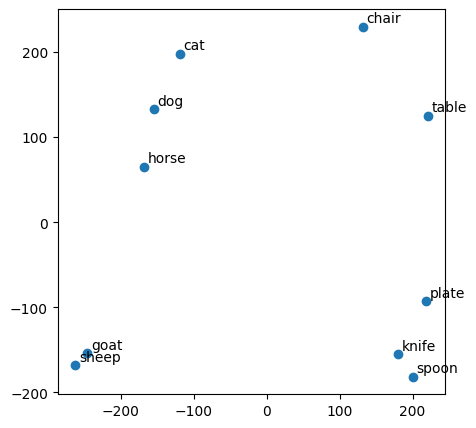

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2) # exactly 2 dimensions (an X and a Y coordinate) so I can draw it on a flat 2D graph
X_pca = pca.fit_transform(token_embeddings)
print(X_pca)
# fit: It analyzes the massive cloud of your high-dimensional token embeddings to find the two directions
# (the Principal Components) where the data varies or spreads out the most. It tries to figure out how to flatten the data while losing the least amount of information.
# transform: It projects your original embeddings onto those two new axes.

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(X_pca[:, 0], X_pca[:, 1])
for i, word in enumerate(words):
    ax.text(X_pca[i, 0]+5, X_pca[i, 1]+5, word)

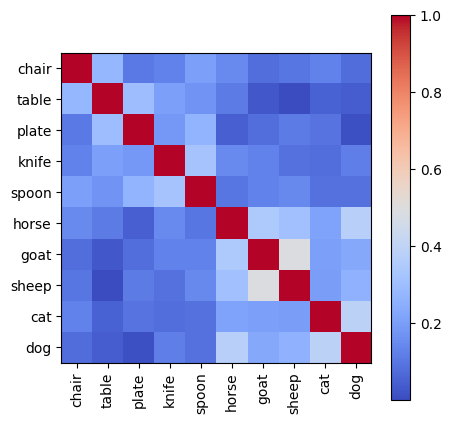

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity(token_embeddings)
fig, ax = plt.subplots(figsize=(5,5))
cax = ax.imshow(cosine_similarity(token_embeddings), cmap="coolwarm")
fig.colorbar(cax)
plt.xticks(range(len(words)), words, rotation=90)
plt.yticks(range(len(words)), words);

### Encoder


The model's encoder contains various transformer layers (each one attention, feed-forward, and normalization layers).

In [29]:
model.encoder

T5Stack(
  (embed_tokens): Embedding(32128, 768)
  (block): ModuleList(
    (0): T5Block(
      (layer): ModuleList(
        (0): T5LayerSelfAttention(
          (SelfAttention): T5Attention(
            (q): Linear(in_features=768, out_features=768, bias=False)
            (k): Linear(in_features=768, out_features=768, bias=False)
            (v): Linear(in_features=768, out_features=768, bias=False)
            (o): Linear(in_features=768, out_features=768, bias=False)
            (relative_attention_bias): Embedding(32, 12)
          )
          (layer_norm): T5LayerNorm()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (1): T5LayerFF(
          (DenseReluDense): T5DenseActDense(
            (wi): Linear(in_features=768, out_features=3072, bias=False)
            (wo): Linear(in_features=3072, out_features=768, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
            (act): ReLU()
          )
          (layer_norm): T5LayerNorm()
          (d

The `block` attribute is a list of `T5Block` modules, and contains the actual transformer layers. Indeed, we can check (as previously stated) that we have 12 encoder layers in the encoder.

In [30]:
len(model.encoder.block)

12

Each of the modules inside of the `block` is composed of a `T5LayerSelfAttention` module (attention layer), followed by a `T5LayerFF` module (feed-forward layer).

Remember that there are some other details (e.g., normalization layers, or dropouts) that are shown below, but we will not discuss them in detail here.

As a reminder, this is the architecture of a single encoder block.

![encoder.png](https://github.com/leilaalizadeh/LLMlabs/blob/main/lab02/images/encoder.png?raw=1)

In [31]:
model.encoder.block[0]

T5Block(
  (layer): ModuleList(
    (0): T5LayerSelfAttention(
      (SelfAttention): T5Attention(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
        (relative_attention_bias): Embedding(32, 12)
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): T5LayerFF(
      (DenseReluDense): T5DenseActDense(
        (wi): Linear(in_features=768, out_features=3072, bias=False)
        (wo): Linear(in_features=3072, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (act): ReLU()
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
)

Notice that the $W_q$, $W_k$, and $W_v$ matrices are 768x768. But, we stated that each attention is 64-dimensional, so they should be 768x64!

However, remember that we have 12 heads: instead of producing 12 different heads, we instead efficiently represent all matrices inside of a single matrix. In addition, there is no need for concatenating the results: the output will already be the concatenation of all heads.

The $W_o$ matrix is 768x768, i.e. `d_kv`*`num_heads` x `d_model`, as expected.

### Decoder

We can inspect the decoder in the same way. Remember the decoder's architecture!

![decoder.png](https://github.com/leilaalizadeh/LLMlabs/blob/main/lab02/images/decoder.png?raw=1)

In [32]:
model.decoder.block[0]

T5Block(
  (layer): ModuleList(
    (0): T5LayerSelfAttention(
      (SelfAttention): T5Attention(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
        (relative_attention_bias): Embedding(32, 12)
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): T5LayerCrossAttention(
      (EncDecAttention): T5Attention(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): T5LayerFF(
      (DenseReluDense): T5DenseA

Indeed, we find the expected architecture.

An initial self-attention module, followed by a multi-head attention one (`T5LayerCrossAttention`), and finally a feed-forward module.

Note that, although there is a dedicated class for cross-attention, the module still makes use of the same `T5Attention` class we also used for self-attention. This is because nothing changes in the attention mechanism itself: only the inputs are different.

Finally, note that the model's `lm_head` is a linear layer that takes the output of the decoder (768-dimensional) and maps it to the vocabulary size (32128).

In [33]:
model.lm_head

Linear(in_features=768, out_features=32128, bias=False)

## Token generation

Let's now focus on the token generation process.

Remember, we are working with an encoder-decoder architecture. The encoder processes the input text, and the decoder generates the output text.

The input for the encoder is the tokenized input text. We also need to specify an input for the decoder. The decoder's input will be the currently generated sequence thus far. For the first iteration, there is nothing already generated, so we need to specify a special token to indicate the beginning of the sequence (BOS). For T5, the token will be `<pad_token>`.

In [34]:
import torch

input_sentence = "translate english to german: hello, how are you?"

#TODO: use the tokenizer to tokenize the input sentence as a tensor
tokens = tokenizer(input_sentence, return_tensors="pt")

decoder_input_ids = torch.tensor([[ tokenizer.pad_token_id ]])

In [35]:
print("Encoder's input")
print(tokens["input_ids"])

print()
print("Decoder's input")
print(decoder_input_ids)

Encoder's input
tensor([[13959, 22269,    12, 13692,    10, 21820,     6,   149,    33,    25,
            58,     1]])

Decoder's input
tensor([[0]])


To generate the first output token (after `<pad_token>`), we call the model's __call__ method (or `forward` method) with the input text and the decoder's input.

In [36]:
# **tokens passes the dictionary as keyword arguments (input_ids=..., attention_mask=...)
# performing a Full Forward Pass through the T5 model (encode-decoder model)
# ** syntax is called Dictionary Unpacking.

output = model(**tokens, decoder_input_ids=decoder_input_ids)
print(output.keys())

odict_keys(['logits', 'past_key_values', 'encoder_last_hidden_state'])


We get three outputs:

- `logits`: The logits for each token in the vocabulary. The logits are the output of the linear layer (the `lm_head`) that maps the decoder's output to the vocabulary size. The logits are used to compute the probabilities of each token.

- `past_key_values`: The past key-values of the decoder. This is used to speed up the generation process for future tokens. Remember: the decoder is autoregressive, so we generate one token at a time. Since each token can only pay attention to past tokens, it means that the predictions made for earlier tokens will not change. Thus, we can cache them and not re-compute them. So, if we pas `past_key_values` to the model the next time we call it, it will be faster.

- `encoder_last_hidden_state`: The hidden states of the last layer of the encoder. This is not used for generating the next token, but we may find it useful for other tasks (e.g., summarization).

In [37]:
print(output.logits.shape)
print(output.logits)
print(output.logits[0,0])
# logits are raw, unnormalized scores for every single token in the T5 vocabulary (all 32,128 of them).
# (batch_size, sequence_length, vocab_size).
# [0,0)]
# The first 0 grabs the first sequence in your batch.
# The second 0 grabs the predictions for the first position of the decoder's output.
# You are asking: "Based on the decoder_input_ids I gave you, what is the very next thing you want to say?"

torch.Size([1, 1, 32128])
tensor([[[-20.4737,  -9.7094, -15.2374,  ..., -40.6805, -40.5435, -40.5263]]],
       grad_fn=<UnsafeViewBackward0>)
tensor([-20.4737,  -9.7094, -15.2374,  ..., -40.6805, -40.5435, -40.5263],
       grad_fn=<SelectBackward0>)


The shape of the logits is 1x1x32128. The first dimension is the batch size, the second dimension is the number of tokens in the output sequence (we are still at a single generated token), and the third dimension is the number of tokens in the vocabulary.

So what's the next word going to be? We can use greedy decoding to take the token with the highest probability.

In [38]:
max_proba_token = output.logits[0,0].argmax()
# argmax returns the index (the token ID) of the absolute highest score.
print("Max probability token:", max_proba_token.item())
print("Corresponding token:", tokenizer.decode(max_proba_token))

Max probability token: 2501
Corresponding token: Hall


Looks like we're on the right track. We have a new token, which we can add to our `decoder_input_ids` tensor and continue with the next iteration.


In [39]:
max_proba_token.view(1, 1)
# .view(1, 1) wraps that single number into a 2D matrix so the shapes match
# hstack
# Before: decoder_input_ids might have been just the start token: [[0]]
# New Token: [[1712]]
# After hstack: [[0, 1712]]

tensor([[2501]])

In [40]:
# .view() acts like .reshape(), but assumes that the tensor is contiguous in memory (& is faster)
decoder_input_ids = torch.hstack([decoder_input_ids, max_proba_token.view(1, 1)])
print(decoder_input_ids)
print(tokenizer.decode(decoder_input_ids))

tensor([[   0, 2501]])
['<pad> Hall']


In [41]:
#TODO: use the model to generate the next token
output = model(**tokens, decoder_input_ids=decoder_input_ids)
output.logits.shape

torch.Size([1, 2, 32128])

Now the output has shape 1x2x32128. We have generated two tokens!

The first one, remember, will necessarily be the same as the one we produced before, since the masking mechanism prevents the model from seeing any following token.

But just to be sure, let's decode both tokens.

In [42]:
print(output.logits[0])
print(output.logits[0,0])
# .argmax(axis=1): Instead of finding just one maximum value, axis=1 tells PyTorch to look across the columns (the 32,128 vocabulary words) for each row individually.
# It looks at Row 1 and picks the highest-scoring ID.
# It looks at Row 2 and picks the highest-scoring ID.

tensor([[-20.4737,  -9.7094, -15.2374,  ..., -40.6805, -40.5435, -40.5263],
        [-53.7681, -28.7684, -24.1913,  ..., -74.5831, -74.2262, -74.6238]],
       grad_fn=<SelectBackward0>)
tensor([-20.4737,  -9.7094, -15.2374,  ..., -40.6805, -40.5435, -40.5263],
       grad_fn=<SelectBackward0>)


In [43]:
# 0 -> first (and only) batch
max_proba_tokens = output.logits[0].argmax(axis=1)
print("Token ids: ", max_proba_tokens)
print("Mapped tokens: ", list(map(reverse_vocab.get, max_proba_tokens.tolist())))
print("Decoded string: ", tokenizer.decode(max_proba_tokens))

Token ids:  tensor([2501,   32])
Mapped tokens:  ['▁Hall', 'o']
Decoded string:  Hallo


We are onto something. We could go ahead and generate more tokens manually.

However, we can implement our own generation loop.

In [44]:
# greedy deoding
# Instead of you having to manually take a prediction, glue it to the input, and feed it back to the model,
# the .generate() method does the entire autoregressive loop for you under the hood.
# It will keep predicting and appending new words until it either hits the End-of-Sequence token (</s>) or reaches a maximum length limit.
# do_smaple: True
# Instead of picking the absolute maximum score, it turns the scores into a probability distribution and rolls a weighted die.
# If "cat" has an 80% score and "dog" has a 20% score, it will pick "cat" most of the time, but 1 out of 5 times, it will pick "dog". This gives you diverse, creative, and human-like text!

tokenizer.batch_decode(model.generate(**tokens, do_sample=True))

['<pad> Hallo, wie bist du?</s>']

In [45]:
print(output.logits[0].argmax(axis=1))
print(tokenizer.batch_decode(output.logits[0].argmax(axis=1)))

tensor([2501,   32])
['Hallo']


In [46]:
decoder_input_ids = torch.tensor([[ tokenizer.pad_token_id ]]) # strt - wake the decoder up

max_length = 50
i = 0

while i < max_length and decoder_input_ids[0,-1] != tokenizer.eos_token_id:
    output = model(**tokens, decoder_input_ids=decoder_input_ids)
    max_proba_tokens = output.logits[0].argmax(axis=1)
    print(f"Step {i+1}: {tokenizer.decode(max_proba_tokens)}")
    decoder_input_ids = torch.hstack([decoder_input_ids, max_proba_tokens[-1].view(1, 1)])
    i += 1

Step 1: Hall
Step 2: Hallo
Step 3: Hallo,
Step 4: Hallo, wie
Step 5: Hallo, wie sind
Step 6: Hallo, wie sind Sie
Step 7: Hallo, wie sind Sie?
Step 8: Hallo, wie sind Sie?</s>


Note that we are introducing a `max_length` parameter. This is just in case, to prevent the model from generating an infinite sequence.

Now, turns out that the model has a `generate()` method that does exactly what we just did.

In [47]:
#TODO: use the model to generate a translation of the input sentence
out_tokens = model.generate(**tokens, max_length=max_length)
tokenizer.batch_decode(out_tokens)

['<pad> Hallo, wie sind Sie?</s>']

You may also empirically verify that `model.generate()` is faster than the manual loop. This is because there are some optimizations in the `generate()` method that make the generation process faster (e.g., caching the encoder's outputs, or the previous decoder's hidden states).

## Cross-attention

We can now run the previous code, but now let's compute the cross-attention weights. This will help us understand what the model is paying attention to in the input sequence, when generating the next token.

To compute the attention weights, we need to reload the model, passing the `output_attentions=True` parameter. This will make the model return the attention weights for each layer.

In [62]:
#TODO: load the model that returns also the output of the attentions (output_attentions=True)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, output_attentions=True)
# output_attentions =True
# Don't just give me your final answer; show me exactly what you were thinking and where you were looking when you made your decision

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [65]:
# re-prepare encoder tokens and decoder tokens
# input_sentence = "translate from english to german: hello how are you?"
input_sentence = "translate english to german: hello how are you?"

#TODO: use the tokenizer to tokenize the input sentence as a tensor
tokens = tokenizer(input_sentence, return_tensors="pt")

#TODO: create the token for the decoder input (start with the <pad> token -> tokenizer.pad_token_id)
decoder_input_ids = torch.tensor([[tokenizer.pad_token_id]])

#TODO: use the model to generate the output putting the decoder_input_ids as the first token (decoder_input_ids=decoder_input_ids)
output = model(**tokens, decoder_input_ids=decoder_input_ids)
print(output.keys())

odict_keys(['logits', 'past_key_values', 'decoder_attentions', 'cross_attentions', 'encoder_last_hidden_state', 'encoder_attentions'])


In [66]:
#TODO: pass in the tokenizer.batch_decode the output of the model to get the translation of the input sentence
# `tokenizer.batch_decode() is the funnction that decodes the tokenized output of the model into a string`
tokenizer.batch_decode(model.generate(**tokens,decoder_input_ids=decoder_input_ids))

['<pad> Hallo, wie sind Sie?</s>']

In addition to the previous values, we now have `decoder_attentions`, `cross_attentions`, and `encoder_attentions`.

The names are self-explanatory. We will focus on the cross-attention to understand encoder-decoder interactions.

Each of the decoder's layers has a corresponding cross-attention layer. So we expect to have 12 cross-attention layers. Indeed, the `cross_attention` is a tuple, with 12 elements.

In [60]:
type(output.cross_attentions), len(output.cross_attentions)


(tuple, 12)

The shape of any one of these attentions is the following: 1x12x1x13. Remember:

- the first 1 is the batch size (a single sentence),
- 12 are the attention heads, each one producing an attention mask,
- 1 is the number of tokens passed as input to the decoder (just BOS, for now),
- 11 is the number of tokens in the input sequence.

In [67]:
output.cross_attentions[0].shape ,

torch.Size([1, 12, 1, 11])

In [71]:
output.cross_attentions[0]

tensor([[[[4.4033e-01, 3.7111e-01, 4.6163e-02, 3.6387e-02, 4.5486e-02,
           4.3608e-03, 4.5185e-04, 4.7863e-04, 1.3358e-02, 1.2620e-03,
           4.0620e-02]],

         [[4.1803e-02, 5.8012e-02, 5.3254e-03, 2.3094e-02, 5.6409e-03,
           6.7337e-01, 2.5559e-02, 4.7895e-03, 2.3385e-03, 1.5235e-01,
           7.7149e-03]],

         [[5.5064e-03, 5.4226e-03, 2.6363e-02, 2.5102e-02, 2.5933e-02,
           2.0688e-02, 1.7443e-02, 4.1172e-03, 1.3255e-02, 8.2499e-01,
           3.1179e-02]],

         [[9.6599e-02, 9.8945e-02, 3.1098e-02, 7.2810e-01, 2.8718e-02,
           6.5955e-05, 1.1963e-04, 1.8779e-04, 6.9500e-05, 3.1346e-04,
           1.5784e-02]],

         [[2.1648e-02, 1.9719e-02, 3.3466e-02, 8.7047e-01, 2.9707e-02,
           7.4329e-04, 1.7524e-04, 3.3689e-04, 9.9776e-05, 1.6010e-03,
           2.2032e-02]],

         [[4.4191e-03, 5.2571e-03, 5.1303e-02, 8.3549e-01, 5.2001e-02,
           2.1470e-03, 2.2572e-03, 1.2545e-04, 2.3830e-05, 7.9712e-03,
           3.9002e

In [75]:
# (layer, batch, head, generated_token, input_token)
output.cross_attentions[0][0, :, 0]
# [0] (The Layer): You selected the 1st layer of the decoder. (T5-base has 12 decoder layers in total).
# 0 (The Batch): You selected the first (and likely only) sentence in your batch.

# : (The Heads): You asked for all 12 attention heads.
# Transformers divide their "brain" into multiple heads so they can look at different things simultaneously (e.g., Head 1 looks at grammar, Head 2 looks at verbs).

# 0 (The Generated Token): You selected the very first token the decoder is trying to generate (which is usually the <pad> start token).
# (implicit) : (The Input Tokens): The final dimension maps to every word in your original input sentence.

tensor([[4.4033e-01, 3.7111e-01, 4.6163e-02, 3.6387e-02, 4.5486e-02, 4.3608e-03,
         4.5185e-04, 4.7863e-04, 1.3358e-02, 1.2620e-03, 4.0620e-02],
        [4.1803e-02, 5.8012e-02, 5.3254e-03, 2.3094e-02, 5.6409e-03, 6.7337e-01,
         2.5559e-02, 4.7895e-03, 2.3385e-03, 1.5235e-01, 7.7149e-03],
        [5.5064e-03, 5.4226e-03, 2.6363e-02, 2.5102e-02, 2.5933e-02, 2.0688e-02,
         1.7443e-02, 4.1172e-03, 1.3255e-02, 8.2499e-01, 3.1179e-02],
        [9.6599e-02, 9.8945e-02, 3.1098e-02, 7.2810e-01, 2.8718e-02, 6.5955e-05,
         1.1963e-04, 1.8779e-04, 6.9500e-05, 3.1346e-04, 1.5784e-02],
        [2.1648e-02, 1.9719e-02, 3.3466e-02, 8.7047e-01, 2.9707e-02, 7.4329e-04,
         1.7524e-04, 3.3689e-04, 9.9776e-05, 1.6010e-03, 2.2032e-02],
        [4.4191e-03, 5.2571e-03, 5.1303e-02, 8.3549e-01, 5.2001e-02, 2.1470e-03,
         2.2572e-03, 1.2545e-04, 2.3830e-05, 7.9712e-03, 3.9002e-02],
        [2.2318e-02, 2.1079e-02, 1.1134e-01, 6.3288e-01, 1.1030e-01, 1.2432e-03,
         3.73

Let's look at the first layer's attentions.

We can see that for early stages the attention is mostly focused on identifying the task ("translate", "english", "german").

Interestingly, "german" gets attention from many of the heads, whereas "translate" and "english" are less attended to. We can expect this to be the case since T5 has been trained on various tasks, one of which was translation from english to other languages.

Text(0.5, 1.0, 'Cross-Attention for the First Generated Token')

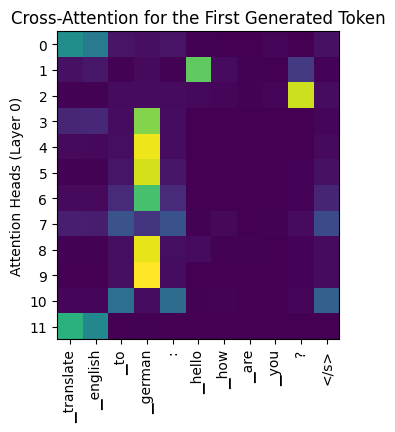

In [82]:
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(output.cross_attentions[0][0, :, 0].detach().numpy())
input_tokens = tokenizer.tokenize(input_sentence) + [ "</s>" ]
ax.set_xticks(range(len(input_tokens)), input_tokens, rotation=90);

ax.set_yticks(range(12))
ax.set_ylabel("Attention Heads (Layer 0)")
ax.set_title("Cross-Attention for the First Generated Token")

# The Y-Axis (Heads): Each row represents one of the 12 attention heads in Layer 0.

# A bright/hot spot (usually yellow/white depending on the default colormap) means:
# "When generating this first word, Head X was paying massive attention to this specific input word."

# A dark spot (purple/blue) means the head ignored that word completely.


We can check the rest of the attentions in the other layers as well.

With the exception of the initial layer, the attention on "translate" and "english" is mostly gone. The attention is now focused on "german" and on the first word of the sentence ("hello").


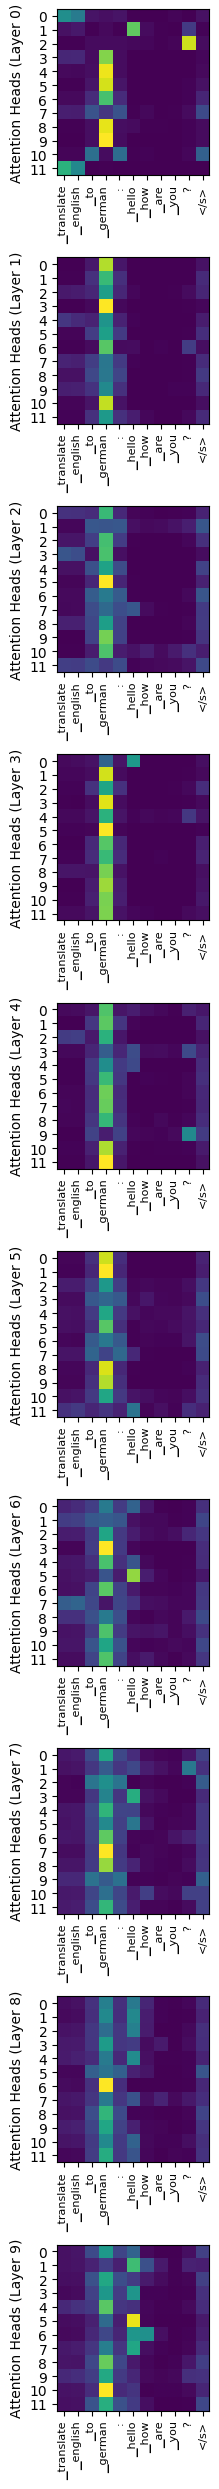

In [99]:
fig, ax = plt.subplots(10, 1, figsize=(10, 25))

ax[0].set_ylabel("Attention head")

for i in range(10):
    ax[i].imshow(output.cross_attentions[i][0, :, 0].detach().numpy())
    input_tokens = tokenizer.tokenize(input_sentence) + [ "</s>" ]
    ax[i].set_xticks(range(len(input_tokens)), input_tokens, rotation=90, fontsize=8);
    ax[i].set_yticks([])
    ax[i].set_yticks(range(12))
    ax[i].set_ylabel(f"Attention Heads (Layer {i})")

plt.tight_layout(h_pad=1.0)

As a final exploration, let's check the average attention across layers and heads, for the last token generated throughout the entire sequence.

In this way, we can observe how the attention shifts as we generate more tokens.

In [100]:
decoder_input_ids = torch.tensor([[ tokenizer.pad_token_id ]])

attns = []

max_length = 50
i = 0

while i < max_length and decoder_input_ids[0,-1] != tokenizer.eos_token_id:
    output = model(**tokens, decoder_input_ids=decoder_input_ids)
    max_proba_tokens = output.logits[0].argmax(axis=1)
    print(f"Step {i+1}: {tokenizer.decode(max_proba_tokens)}")
    decoder_input_ids = torch.hstack([decoder_input_ids, max_proba_tokens[-1].view(1, 1)])
    attns.append(output.cross_attentions)
    i += 1

Step 1: Hall
Step 2: Hallo
Step 3: Hallo,
Step 4: Hallo, wie
Step 5: Hallo, wie sind
Step 6: Hallo, wie sind Sie
Step 7: Hallo, wie sind Sie?
Step 8: Hallo, wie sind Sie?</s>


Note: taking the average across all heads and all layers may not necessarily be the best approach (for instance, some interesting aspects may be lost in this aggregation). However, it should give us a general idea of what the model is focusing on.

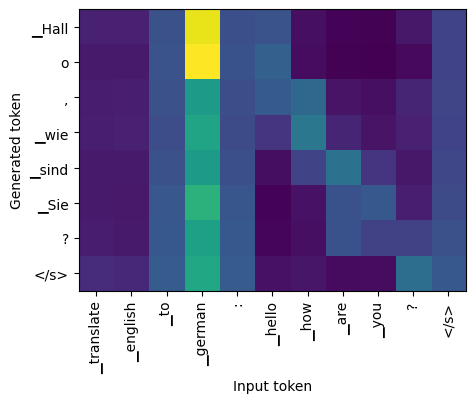

In [101]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(torch.stack([ torch.stack(a).mean(axis=(0, 1, 2))[-1] for a in attns ]).detach().numpy())
ax.set_xlabel("Input token")
ax.set_ylabel("Generated token")

input_tokens = tokenizer.tokenize(input_sentence) + [ "</s>" ]
output_tokens = tokenizer.tokenize(tokenizer.decode(output.logits[0].argmax(axis=1)))
ax.set_xticks(range(len(input_tokens)), input_tokens, rotation=90)
ax.set_yticks(range(len(output_tokens)), output_tokens);

Indeed, when Hall|o|, is generated, the most attention is paid to the word "hello". Then the attention shifts to the rest of the sentence gradually. This shows how the decoder can focus on different parts of the input sequence as it generates different parts of the output sequence!